In [20]:
from autoslo.utils.colors import Palette, set_plot_colors
import autoslo.utils.paths as pu
import os
import yaml
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np  

In [4]:
in_path = os.path.join(pu.AUTOSLO_ROOT, 'experiments', '10_workgroup_initialization_benchmarking', 'logs', 'benchmark_results_20260112_211939.yml')
with open(in_path, 'r') as f:
    results = yaml.safe_load(f)

rpu_results = results['rpu_results']

l = []

for rpu_val in rpu_results:
    all_results_for_rpu = rpu_results[rpu_val]
    for result in all_results_for_rpu:
        
        d=   {
                'rpu': result['data']['meta']['base_rpu'],
                'iteration': result['iteration'],                
            }
        for step in result['data']['steps']:
            d[step['step']] = step['duration_seconds']
        l.append(d)
df = pd.DataFrame(l)
df.head()
    

,rpu,iteration,create_namespace,wait_for_namespace_available,create_workgroup,wait_for_workgroup_available,attach_tpcds_database,create_external_schemas,wait_before_deletion,delete_workgroup,wait_for_workgroup_deleted,delete_namespace,wait_for_namespace_deleted
0,4,1,0.23,0.14,1.62,53.32,3.22,21.11,180.0,0.37,65.33,0.37,136.48
1,4,3,0.24,0.15,1.54,73.38,4.63,93.33,180.0,0.36,71.96,0.34,131.37
2,4,4,0.25,0.16,1.52,53.72,8.55,116.92,180.0,0.37,63.79,0.33,141.85
3,4,5,0.23,0.16,1.65,54.82,3.30,125.00,180.0,0.37,72.77,0.38,133.20
4,4,2,0.23,0.24,1.57,58.58,3.31,21.41,180.0,0.33,60.95,0.20,NaN


In [36]:
# Transform the DataFrame to a long format
df_melted = df.melt(id_vars=['rpu', 'iteration'], var_name='step', value_name='duration_seconds')
df_melted['step_type'] = None


# The steps create_namespace, wait_for_namespace_available, create_workgroup, and
# wait_for_workgroup_available have type "Creation" 
creation_steps = [
    'create_namespace',
    'wait_for_namespace_available',
    'create_workgroup',
    'wait_for_workgroup_available'
]
df_melted.loc[df_melted['step'].isin(creation_steps), 'step_type'] = 'Creation'

# We don't care about the step "wait before deletion" for this plot, so remove it
df_melted = df_melted[df_melted['step'] != 'wait_before_deletion']

# Any step that mentions "delete" is of type "Deletion"
deletion_steps = [step for step in df_melted['step'].unique() if 'delete' in step]
df_melted.loc[df_melted['step'].isin(deletion_steps), 'step_type'] = 'Deletion'

# The steps "attach_tpcds_database" and "create_external_schema" are of type "Setup"
setup_steps = [
    'attach_tpcds_database',
    'create_external_schema'
]
df_melted.loc[df_melted['step'].isin(setup_steps), 'step_type'] = 'Setup'

# Per rpu, iteration, and step_type, sum the duration_seconds
df_summarized = df_melted.groupby(['rpu', 'iteration', 'step_type'], as_index=False)['duration_seconds'].sum()
df_summarized.head()

,rpu,iteration,step_type,duration_seconds
0,4,1,Creation,55.31
1,4,1,Deletion,202.55
2,4,1,Setup,3.22
3,4,2,Creation,60.62
4,4,2,Deletion,61.48


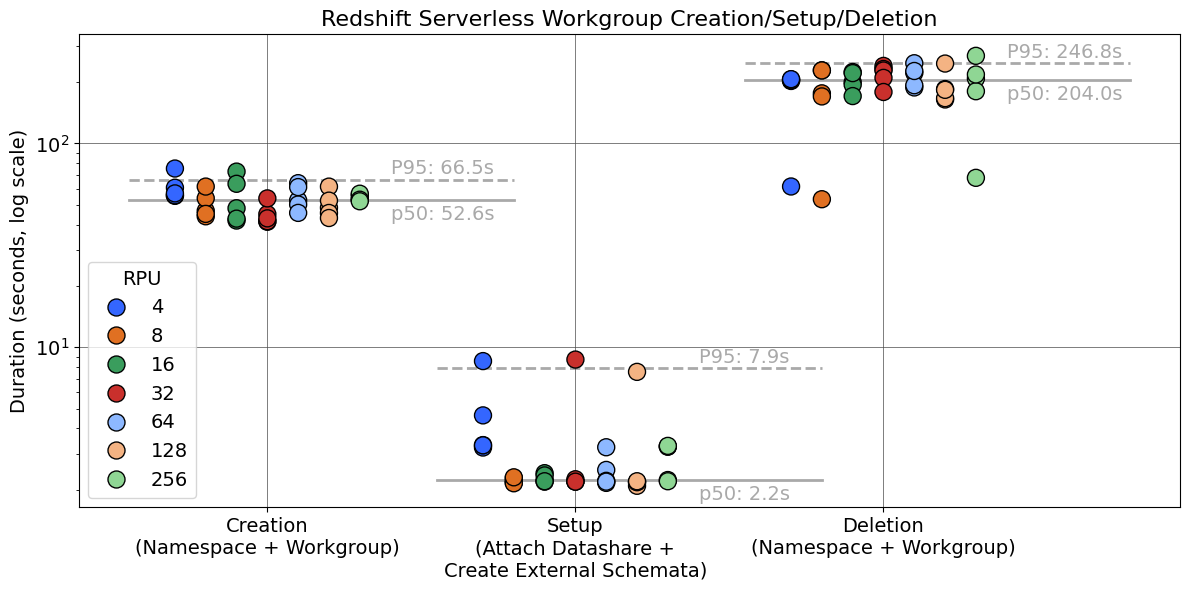

In [85]:
# Plot the results as a scatter plot, where the y axis is time in seconds (log scale),
# the x axis is the different step types in order, and the color is the rpu value.

# Slightly stagger the x axis positions based on rpu value for better visibility
step_type_order = ['Creation', 'Setup', 'Deletion']
df_summarized['step_type'] = pd.Categorical(df_summarized['step_type'], categories=step_type_order, ordered=True)


plt.figure(figsize=(12, 6))
num_unique_rpu = df['rpu'].nunique()
colors = Palette.as_list()[:num_unique_rpu]


labels = [
    'Creation\n(Namespace + Workgroup)',
    'Setup\n(Attach Datashare +\nCreate External Schemata)',
    'Deletion\n(Namespace + Workgroup)'
]

# Derive the x positions with slight offsets
base_x_positions = np.arange(len(step_type_order))
rpu_values = sorted(df_summarized['rpu'].unique())
rpu_to_offset = {rpu: (i - num_unique_rpu // 2) * 0.1 for i, rpu in enumerate(rpu_values)}
df_summarized['x_position'] = df_summarized.apply(lambda row: base_x_positions[step_type_order.index(row['step_type'])] + rpu_to_offset[row['rpu']], axis=1)


plt.xticks(ticks=base_x_positions, labels=labels)


# Have the plot background be white
plt.gca().set_facecolor(Palette.white)

# Make all fonts larger
fontsize=14
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xticks(rotation=0)

# For each step type, draw a line at the median and p95 across RPU values
offset = num_unique_rpu * 0.1 / 2
for step_type in step_type_order:
    step_subset = df_summarized[df_summarized['step_type'] == step_type]
    median = step_subset['duration_seconds'].median()
    p95 = step_subset['duration_seconds'].quantile(0.95)
    x_pos = base_x_positions[step_type_order.index(step_type)]
    plt.plot([x_pos - offset-0.1, x_pos + offset+0.45], [median, median], color='darkgray', linewidth=2, zorder=1)
    plt.plot([x_pos - offset-0.1, x_pos + offset+0.45], [p95, p95], color='darkgray', linewidth=2, linestyle='--', zorder=1)

    # To the right of the line, annotate its value.
    # Expet
    plt.text(x_pos + offset+0.05, median*0.95, f'p50: {median:.1f}s', va='top', fontsize=fontsize, color='darkgray')
    plt.text(x_pos + offset + 0.05, p95*1.02, f'P95: {p95:.1f}s', va='bottom', fontsize=fontsize, color='darkgray')


# Draw the points on top of the gray lines
sns.scatterplot(
    data=df_summarized,
    x='x_position',
    y='duration_seconds',
    hue='rpu',
    palette=colors,
    s=150,
    edgecolor='k',
    zorder=2
)




plt.yscale('log')
plt.title('Redshift Serverless Workgroup Creation/Setup/Deletion', fontsize=fontsize+2)
plt.xlabel(None)
plt.ylabel('Duration (seconds, log scale)', fontsize=fontsize)
plt.legend(title='RPU', facecolor=Palette.white, fontsize=fontsize, title_fontsize=fontsize)
plt.grid(True, which="major", linewidth=0.5)
plt.tight_layout()
plt.savefig('workgroup_creation_benchmarking.svg', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>